In [1]:
!pip uninstall -y numpy
!pip install "numpy<2.0"

!pip install torch==2.2.2 torchvision==0.17.2 monai
!pip install scikit-image
!pip install wandb
!pip install import-ipynb
!pip install nibabel 


Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
ERROR: Exception:
Traceback (most recent call last):
  File "/usr/lib/python3.10/shutil.py", line 816, in move
    os.rename(src, real_dst)
PermissionError: [Errno 13] Permission denied: '/usr/local/lib/python3.10/dist-packages/numpy-1.26.4.dist-info/' -> '/tmp/pip-uninstall-usjaypr_'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/pip/_internal/cli/base_command.py", line 107, in _run_wrapper
    status = _inner_run()
  File "/usr/local/lib/python3.10/dist-packages/pip/_internal/cli/base_command.py", line 98, in _inner_run
    return self.run(options, args)
  File "/usr/local/lib/python3.10/dist-packages/pip/_internal/commands/uninstall.py", line 105, in run
    uninstall_pathset = req.uninstall(
  File "/usr/local/lib/python3.10/dist-packages/pip/_internal/req/req_install.py", line 675, in uninstall
    uninstalle

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import glob
import monai
import torch
import re
import torchvision.transforms as transforms
from PIL import Image
from monai.transforms import LoadImage
import import_ipynb
from Functions import patients_dicts
from monai.data import MetaTensor

zip_file = "Resources.zip"
os.makedirs("train", exist_ok=True)
!unzip -o -q {zip_file} -d {"train"}
data_path = "train"


full_dict_list = patients_dicts(data_path)

In [3]:
zip_file_test = "Resources_test.zip"
os.makedirs("test",exist_ok=True)
!unzip -o -q {zip_file_test} -d {"test"}
data_path_test = "test"

test_dict_list = patients_dicts(data_path_test)

In [4]:
print(len(full_dict_list))
print(len(test_dict_list))

100
50


In [5]:
import random

def split_dataset(dataset, per_train=16, per_val=4, seed=None):
    
    if seed is not None:
        random.seed(seed)
        
    catogories_numbers = {}
    catogories_ID = {}

    for patient in dataset:
        disease = patient["Disease"]
        if disease not in catogories_numbers:
            catogories_numbers[disease] = 0
            catogories_ID[disease] = []
        catogories_numbers[disease] += 1
        catogories_ID[disease].append(patient)
        
    split_train_dataset = []
    split_val_dataset = []
    
    for disease, patientIDS in catogories_ID.items():
        random.shuffle(patientIDS)

        train_ids = patientIDS[:per_train]
        val_ids = patientIDS[per_train:per_train+per_val]

        split_train_dataset.extend(train_ids)
        split_val_dataset.extend(val_ids)

    return split_train_dataset, split_val_dataset

In [6]:
from Functions import par_voxelsize, par_size
from monai.transforms import LoadImaged, Compose, EnsureChannelFirstd,ScaleIntensityd, Spacingd,LoadImaged, ResizeWithPadOrCropd

data_transform = Compose([
    LoadImaged(keys=["imgED", "maskED", "imgES", "maskES"], image_only=False),
    EnsureChannelFirstd(keys=["imgED","maskED","imgES","maskES"], channel_dim="no_channel")])

train_dataset_raw = monai.data.Dataset(full_dict_list, transform=data_transform)

voxel_size = []
mean_voxel, std_voxel, max_voxelsize = par_voxelsize(voxel_size,train_dataset_raw)

print("Median voxel size:", mean_voxel)
print("Std voxel size:", std_voxel)
print("Max voxel size:", max_voxelsize)

"""
sizes = []
max_size, listofsizes = par_size(sizes,train_dataset_raw)
print("Max image size:", max_size)
print(listofsizes)
"""

Median voxel size: [ 1.5625  1.5625 10.    ]
Std voxel size: [0.18463361 0.18463361 1.6644143 ]
Max voxel size: [ 1.91964  1.91964 10.     ]


'\nsizes = []\nmax_size, listofsizes = par_size(sizes,train_dataset_raw)\nprint("Max image size:", max_size)\nprint(listofsizes)\n'

In [9]:
from monai.transforms import LoadImaged, Compose, EnsureChannelFirstd,ScaleIntensityd, Spacingd,LoadImaged, ResizeWithPadOrCropd, NormalizeIntensityd, RandFlipd, RandRotated, RandGaussianSmoothd 

val_data_transform = Compose([
    LoadImaged(keys=["imgED", "maskED", "imgES", "maskES"], image_only=False),
    EnsureChannelFirstd(keys=["imgED","maskED","imgES","maskES"], channel_dim="no_channel"),
    Spacingd(keys=["imgED","maskED","imgES","maskES"], pixdim=(mean_voxel[0],mean_voxel[1],mean_voxel[2]), mode=("bilinear", "nearest","bilinear", "nearest"),
                ensure_same_shape=True,align_corners=False),
    ResizeWithPadOrCropd(keys=["imgED","maskED","imgES","maskES"],spatial_size=(256,256,16)), #added cause the images needed to be devided by 16 for the strides in the Unet image
    NormalizeIntensityd(keys=["imgED", "imgES"], nonzero=True, channel_wise=True)
])

train_data_transform = Compose([
    LoadImaged(keys=["imgED", "maskED", "imgES", "maskES"], image_only=False),
    EnsureChannelFirstd(keys=["imgED","maskED","imgES","maskES"], channel_dim="no_channel"),
    Spacingd(keys=["imgED","maskED","imgES","maskES"], pixdim=(mean_voxel[0],mean_voxel[1],mean_voxel[2]), mode=("bilinear", "nearest","bilinear", "nearest"),
                ensure_same_shape=True,align_corners=False),
    ResizeWithPadOrCropd(keys=["imgED","maskED","imgES","maskES"],spatial_size=(256,256,16)),#added cause the images needed to be devided by 16 for the strides in the Unet image we can look into if we can solve this an other way
    NormalizeIntensityd(keys=["imgED", "imgES"], nonzero=True, channel_wise=True),
    RandFlipd(keys=["imgED", "maskED", "imgES", "maskES"], prob=0.33, spatial_axis=[0, 1, 2]),
    RandRotated(
        keys=["imgED", "maskED", "imgES", "maskES"],
        range_x=0.4, 
        prob=0.33,
        mode=["bilinear", "nearest", "bilinear", "nearest"]
    ),
    RandGaussianSmoothd(keys=["imgED", "imgES"], prob = 0.33)

])


#using the split function to split the data
train_dict_list, val_dict_list = split_dataset(full_dict_list, per_train=16, per_val=4, seed=10)

train_dataset = monai.data.Dataset(train_dict_list, transform=train_data_transform)
val_dataset   = monai.data.Dataset(val_dict_list, transform=val_data_transform)

train_loader = monai.data.DataLoader(train_dataset, batch_size=1, collate_fn=monai.data.pad_list_data_collate)
val_loader = monai.data.DataLoader(val_dataset, batch_size=1, collate_fn=monai.data.pad_list_data_collate)

print("Validation dataset size", len(val_dict_list))

#for sample in train_dataset:
#    aff = sample["imgED"].meta["affine"]
#    spacing = np.sqrt((aff[:3, :3]**2).sum(0))
#    print( "spacing:", spacing, "shape:", tuple(sample["imgED"].shape))

Validation dataset size 20


In [10]:
def visualize_heart_sample(sample, title=None):
    # Visualize the x-ray and overlay the mask, using the dictionary as input
    for i in range(2):
        if i == 0:
            image = np.squeeze(sample['imgED'])
            mask = np.squeeze(sample['maskED'])
        else:
            image = np.squeeze(sample['imgES'])
            mask = np.squeeze(sample['maskES'])

        plt.figure(figsize=[10,7])
        plt.imshow(image, 'gray')

        mask1 = np.ma.masked_where(mask != 1, mask)
        plt.imshow(mask1, 'Greens', alpha = 0.5, clim=[0,1], interpolation='nearest')

        mask2 = np.ma.masked_where(mask != 2, mask)
        plt.imshow(mask2, 'Reds', alpha = 0.5, clim=[0,1], interpolation='nearest')

        mask3 = np.ma.masked_where(mask != 3, mask)
        plt.imshow(mask3, 'Blues', alpha = 0.5, clim=[0,1], interpolation='nearest')
        if title is not None:
            plt.title(title)
        plt.show()

#shape = train_dataset[0]['imgED'].shape
#for i in range(shape[3]):
#    single_data = train_dataset[0]
#    sample_slice = {
#    'imgED': single_data['imgED'][0,:, :, i],
#    'maskED': single_data['maskED'][0,:, :, i],
#    'imgES': single_data['imgES'][0,:, :, i],
#    'maskES': single_data['maskES'][0,:, :, i]
#    }
#    visualize_heart_sample(sample_slice, title=f"patient:{single_data['ID']},disease:{single_data['Disease']},slice:{i}")

In [11]:
#Defining the Unet model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f'The used device is {device}')

model = monai.networks.nets.UNet(
    spatial_dims=3,
    in_channels=1, 
    out_channels=4, #since we want to segment 3 heart areas+ back
    channels=(8, 16, 32, 64, 128), #checking if the chanels are correct
    strides=(2, 2, 2, 2),
    #num_res_units=2,
).to(device)


The used device is cuda


In [12]:
#weight decays
epochs= 250 #looking if we want to change
batch = 1 
learning_rate = 1e-3
loss_function =  monai.losses.DiceLoss(softmax=True,to_onehot_y=True,batch=True) #Dice loss because segmentation
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3) #look in to if we want to keep using Adam or if we want an other optimizer

In [13]:

import wandb
wandb.login()#make sure you're in the right prodject!! 

run = wandb.init(
    project='Deep_learning_project',
    name='all_patients_run_ED_ES_augmentatie',
    config={
        'loss function': str(loss_function), 
        'lr': optimizer.param_groups[0]["lr"],
        'transform': [str(t) for t in train_data_transform.transforms],
        'batch_size': train_loader.batch_size,
    }
)

def wandb_masks(mask_output, mask_gt):
    """Generate mask dictionary for W&B logging."""
    # Convert model output to class predictions
    mask_output = torch.softmax(mask_output, dim=1)  # shape: (B, C, H, W, D)
    mask_output = torch.argmax(mask_output, dim=1).cpu().numpy()

    # Convert ground truth to class indices if one-hot
    if mask_gt.shape[1] > 1:  # check if one-hot
        mask_gt = torch.argmax(mask_gt, dim=1)
    mask_gt = mask_gt.cpu().numpy()

    class_labels = {0: 'background', 1: 'right_ventricle', 2: 'left_ventricle', 3: 'myocardium'}
    masks = {
        'predictions': {'mask_data': mask_output, 'class_labels': class_labels},
        'ground_truth': {'mask_data': mask_gt, 'class_labels': class_labels}
    }
    return masks

    # Create list of images that have segmentation masks for model output and ground truth
def log_to_wandb(epoch, batch_data, outputs, frame='ED'):
    img = batch_data[f'img{frame}'][0].cpu().numpy()
    mask_gt = batch_data[f'mask{frame}'][0].float().to(device)
    mask_output = outputs
    wandb_img = wandb.Image(img, masks=wandb_masks(mask_output, mask_gt))
    wandb.log({f'results_{frame}': wandb_img, 'epoch': epoch})
    
    #log_to_wandb(epoch, loss.item(), None, batch, outputED, frame='ED')
    #log_to_wandb(epoch, loss.item(), None, batch, outputES, frame='ES')

# Store the network parameters        
torch.save(model.state_dict(), r'trainedUNet.pt')

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/jovyan/.netrc.
wandb: Currently logged in as: jinte (f-y-vandenberg-university-of-twente) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [14]:
import tqdm


def train_medmnistmodel(model, train_dataloader, val_dataloader, optimizer, epochs, val_freq=2,log_images=True):
    train_loss = []
    val_loss = []
    for epoch in tqdm.tqdm(range(epochs)):
        model.train()
        steps = 0
        epoch_loss = 0
        for batch in train_dataloader: #250 steps per epoch, figure out how many steps we need, going to the data once, early stopping if patient level =15
            optimizer.zero_grad() #backropagation
            imagED = batch['imgED'].float().to(device)
            labelsED = batch['maskED'].long().to(device)
            imagES = batch['imgES'].float().to(device)
            labelsES = batch['maskES'].long().to(device)
            outputED = model(imagED)
            outputES = model(imagES)
            loss = (loss_function(outputED, labelsED)+loss_function(outputES, labelsES))/2
            epoch_loss += loss.item()
            loss.backward()
            optimizer.step()
            steps += 1
            
        if log_images and steps % 50 == 0:
                log_to_wandb(epoch, batch, outputED, frame='ED')
                log_to_wandb(epoch, batch, outputES, frame='ES')
        avg_train_loss = epoch_loss / steps        
        train_loss.append(avg_train_loss)


        if epoch % val_freq == 0:
            val_steps = 0
            val_epoch_loss = 0
            model.eval()
            for batch in val_dataloader:
                imagED = batch['imgED'].float().to(device)
                labelED = batch['maskED'].float().to(device)
                imagES = batch['imgES'].float().to(device)
                labelES = batch['maskES'].float().to(device)
                outputED = model(imagED)
                outputES = model(imagES)
                loss = (loss_function(outputED, labelED)+loss_function(outputES,labelES))/2
                val_epoch_loss += loss.item()
                val_steps += 1
            avg_val_loss = val_epoch_loss / val_steps
            val_loss.append(avg_val_loss)
            wandb.log({'epoch': epoch,'train_loss': avg_train_loss,'val_loss': avg_val_loss})
            
    torch.save(model.state_dict(), 'trainedUNet.pt')
    wandb.finish()
    return train_loss, val_loss, model

In [15]:
#applying the training set
train_loss, val_loss, model = train_medmnistmodel(model, train_loader, val_loader, optimizer, epochs=epochs)

100%|██████████| 250/250 [1:18:52<00:00, 18.93s/it]


epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▄▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇█████
train_loss,█▇▅▄▄▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_loss,█▅▄▄▄▄▃▃▂▂▂▂▂▂▁▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,248
train_loss,0.23506
val_loss,0.3243


In [16]:
test_data_transform = Compose([
    LoadImaged(keys=["imgED", "maskED", "imgES", "maskES"], image_only=False),
    EnsureChannelFirstd(keys=["imgED","maskED","imgES","maskES"], channel_dim="no_channel"),
    Spacingd(keys=["imgED","maskED","imgES","maskES"], pixdim=(mean_voxel[0],mean_voxel[1],mean_voxel[2]), mode=("bilinear", "nearest","bilinear", "nearest"),
                ensure_same_shape=True,align_corners=False),
    ResizeWithPadOrCropd(keys=["imgED","maskED","imgES","maskES"],spatial_size=(256,256,16)), #added cause the images needed to be devided by 16 for the strides in the Unet image
    NormalizeIntensityd(keys=["imgED", "imgES"], nonzero=True, channel_wise=True)
])

test_dataset = monai.data.Dataset(test_dict_list, transform=test_data_transform)
test_loader = monai.data.DataLoader(test_dataset, batch_size=1, collate_fn=monai.data.pad_list_data_collate)

In [17]:
import torch.nn.functional as F

def compute_metric(dataloader, model, metric_fn):
    """
    This function computes the average value of a metric for a data set.
    
    Args:
        dataloader (monai.data.DataLoader): dataloader wrapping the dataset to evaluate.
        model (torch.nn.Module): trained model to evaluate.
        metric_fn (function): function computing the metric value from two tensors:
            - a batch of outputs,
            - the corresponding batch of ground truth masks.
        
    Returns:
        (float) the mean value of the metric
    """
    model.eval()
    inferer = monai.inferers.SlidingWindowInferer(roi_size=[256, 256, 16])
    
    metric_fn.reset()
 
    for sample in dataloader:
        with torch.no_grad():
            for phase in ["ED", "ES"]:

                image = sample[f"img{phase}"].to(device)
                mask  = sample[f"mask{phase}"].to(device)

                output = inferer(image, network=model)
                
                model_mask = torch.argmax(output, dim=1)
                model_mask = torch.nn.functional.one_hot(model_mask, num_classes=4)
                model_mask = model_mask.permute(0, 4, 1, 2, 3).float()

                gt_mask = torch.nn.functional.one_hot(
                    mask.long().squeeze(1), num_classes=4
                ).permute(0, 4, 1, 2, 3).float()

                """
                # to print prediction of model:
                print(f"\n--- {phase} ---")
                for c in range(4):
                    pred_sum = model_mask[:, c].sum().item()
                    gt_sum   = gt_mask[:, c].sum().item()
                    print(f"class {c}: pred={pred_sum}, gt={gt_sum}")
                """
                    
                metric_fn(y_pred=model_mask, y=gt_mask)
    return metric_fn.aggregate().item()


In [20]:
metric_fn = monai.metrics.HausdorffDistanceMetric(include_background=False, percentile=95,
    reduction="mean")
Hausdorff_dist =  compute_metric(test_loader, model, metric_fn)
# run.summary["Hausdorff_dist"] = Hausdorff_dist
print(f"Hausdorff distance on test set: {Hausdorff_dist:.3f}")

Hausdorff distance on test set: 12.860


In [21]:
metric_fn = monai.metrics.DiceMetric(include_background=False, reduction="mean")
dice = compute_metric(test_loader, model, metric_fn)
# run.summary["dice"] = dice
print(f"Dice on test set: {dice:.3f}")

Dice on test set: 0.562


In [102]:
def overlay_multiclass(ax, mask):
    import numpy as np

    mask = np.round(mask).astype(int)
    overlay = np.zeros((*mask.shape, 4), dtype=float)

    overlay[mask == 1] = [0, 1, 0, 0.8]
    overlay[mask == 2] = [1, 0, 0, 0.8]
    overlay[mask == 3] = [0, 0, 1, 0.8]

    ax.imshow(overlay, interpolation= "nearest")

def visual_evaluation(sample, model, indxslice=None):
    model.eval()
    inferer = monai.inferers.SlidingWindowInferer(roi_size=[256, 256, 16])
    
    with torch.no_grad():
        for phase in ["ED", "ES"]:
            image = sample[f"img{phase}"].unsqueeze(0).to(device)
            mask  = sample[f"mask{phase}"].unsqueeze(0).to(device)

            output = inferer(image, network=model)
                
            model_mask = torch.argmax(output, dim=1)
            model_labels = model_mask.squeeze().cpu().numpy()
            gt_labels = mask.squeeze().cpu().numpy()
            image = image.squeeze().cpu().numpy()
            
            if indxslice is None:
                indxslice = image.shape[-1] //2
            
            fig, ax = plt.subplots(1,3,figsize=(15,5))
            
            ax[0].imshow(image[:,:,indxslice], cmap='gray')
            ax[0].set_title(f"{sample['ID']} - {phase} image")
            
            ax[1].imshow(image[:,:,indxslice], cmap='gray')
            overlay_multiclass(ax[1], gt_labels[:,:,indxslice])
            ax[1].set_title(f"{sample['ID']} - {phase} ground truth")

            ax[2].imshow(image[:,:,indxslice], cmap='gray')
            overlay_multiclass(ax[2], model_labels[:,:,indxslice])
            ax[2].set_title(f"{sample['ID']} - {phase} prediction")
            
            print(np.unique(mask))
            print(np.unique(model_mask))

            plt.show()

[0. 1. 2. 3.]
[0 1 2 3]


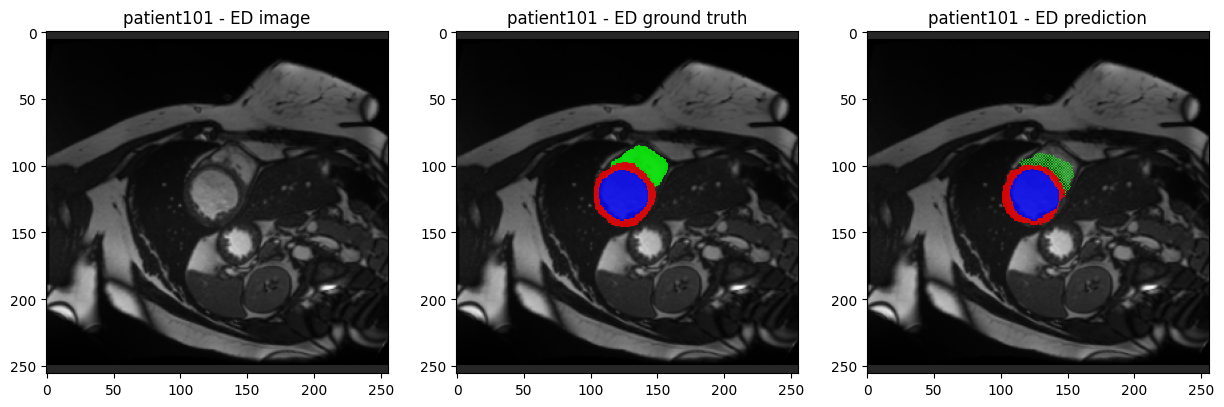

[0. 1. 2. 3.]
[0 1 2 3]


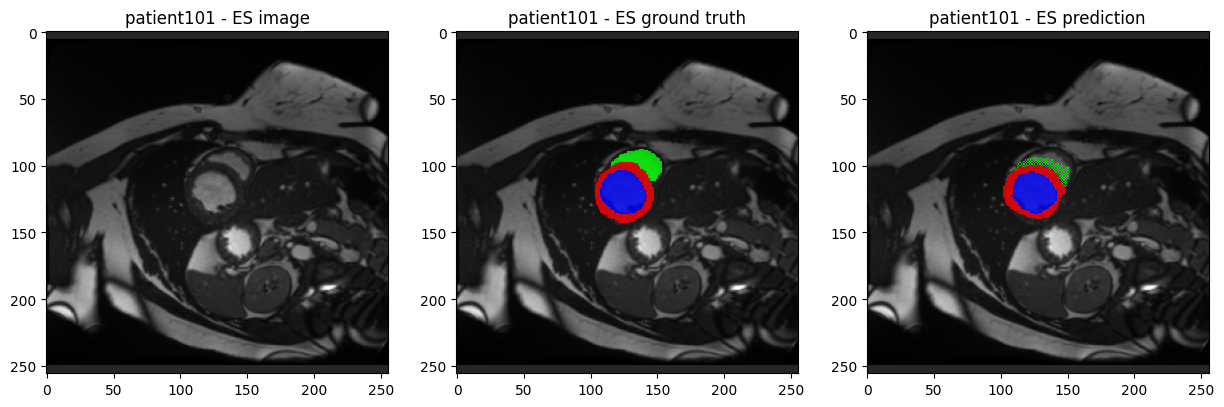

[0. 1. 2. 3.]
[0 1 2 3]


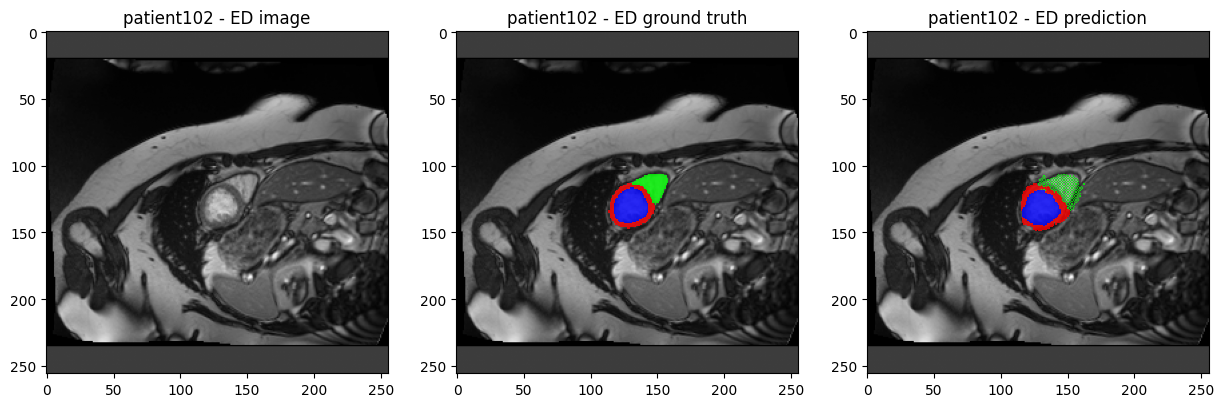

[0. 1. 2. 3.]
[0 1 2 3]


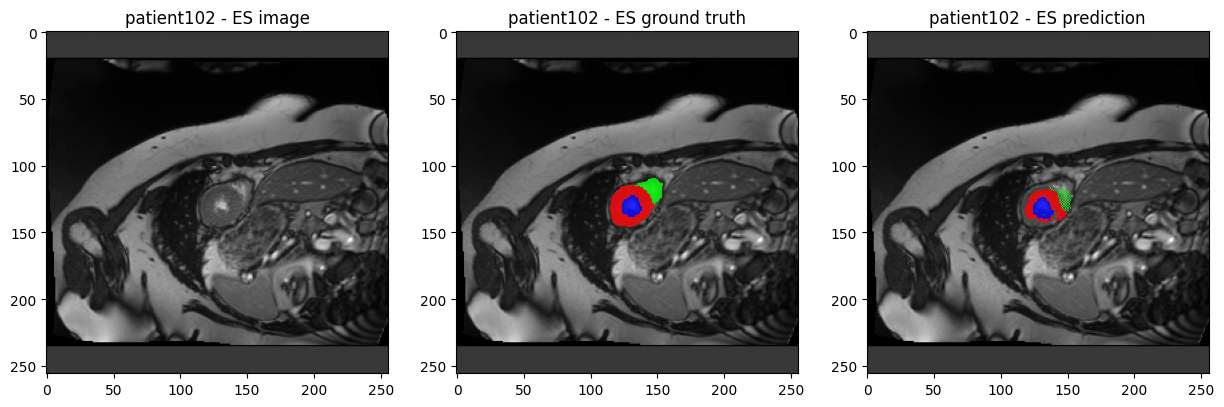

[0. 1. 2. 3.]
[0 1 2 3]


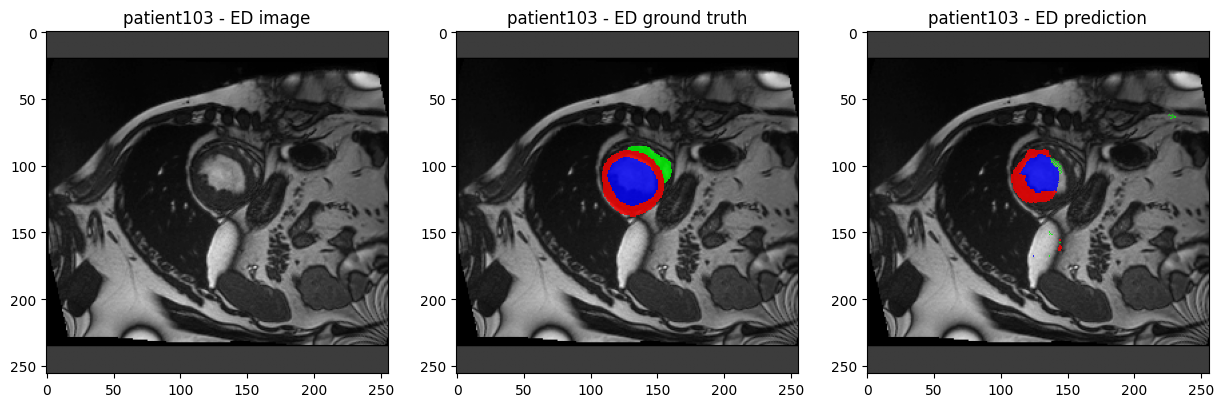

[0. 1. 2. 3.]
[0 1 2 3]


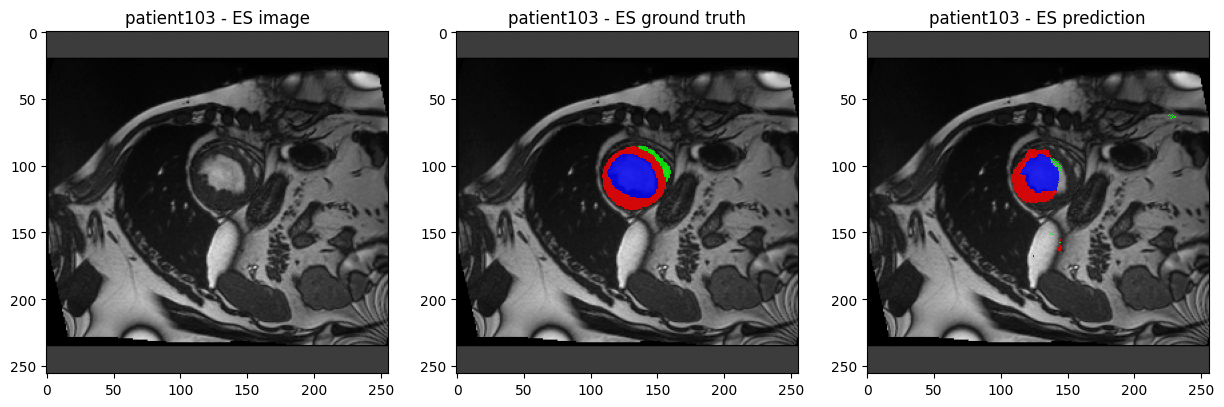

[0. 1. 2. 3.]
[0 1 2 3]


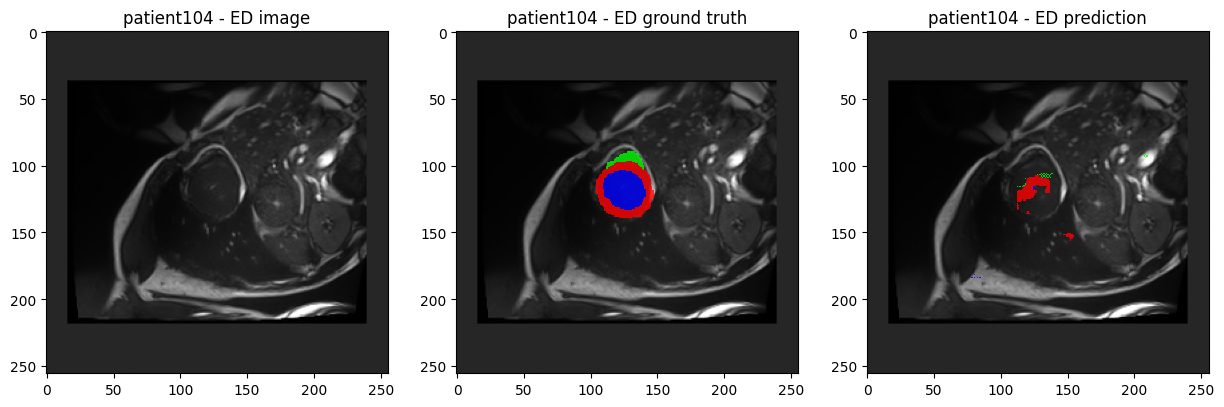

[0. 1. 2. 3.]
[0 1 2 3]


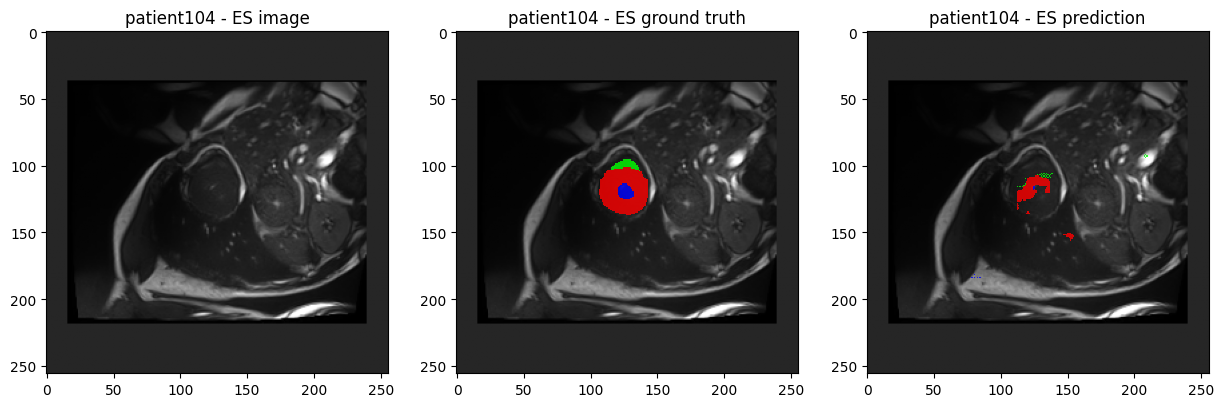

[0. 1. 2. 3.]
[0 1 2 3]


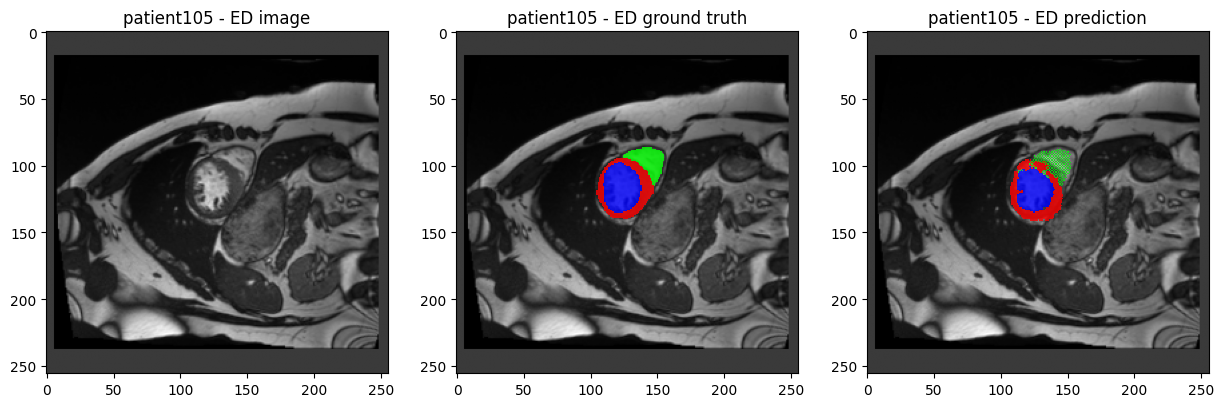

[0. 1. 2. 3.]
[0 1 2 3]


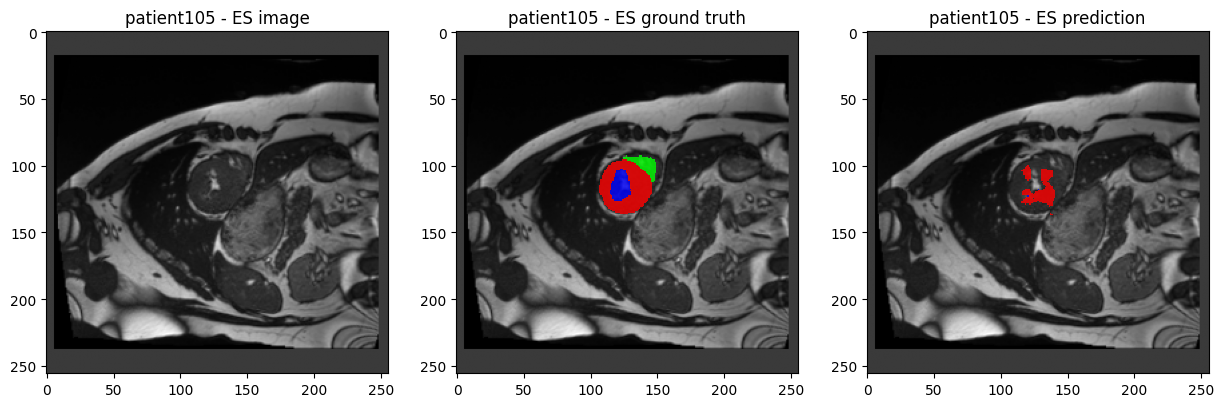

[0. 1. 2. 3.]
[0 1 2 3]


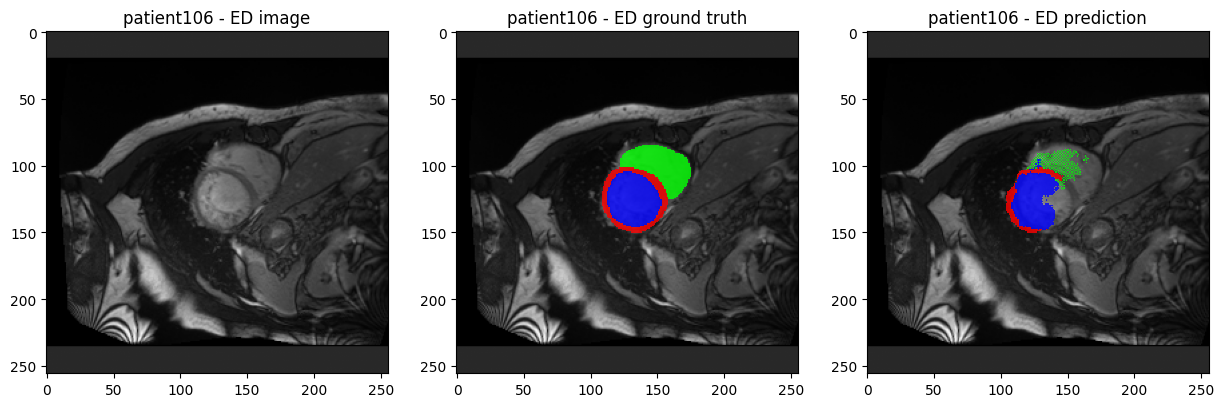

[0. 1. 2. 3.]
[0 1 2 3]


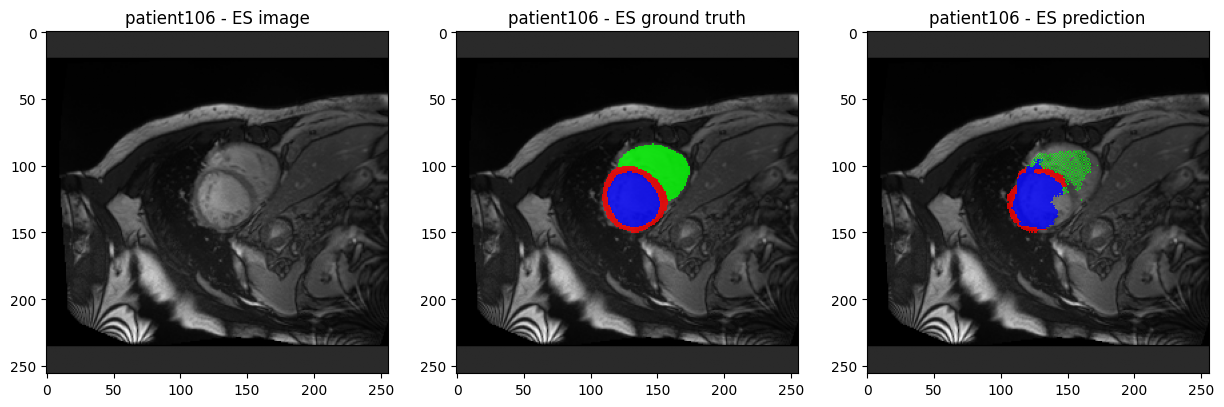

[0. 1. 2. 3.]
[0 1 2 3]


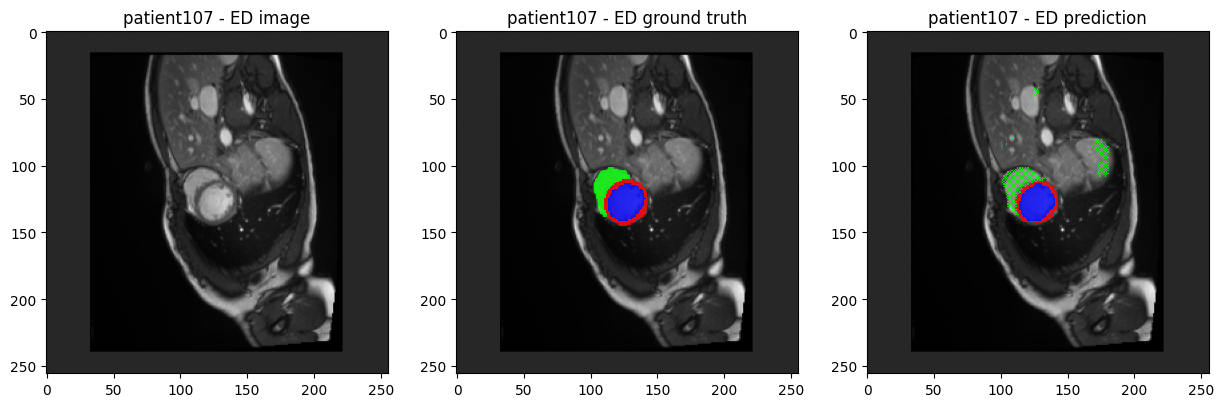

[0. 1. 2. 3.]
[0 1 2 3]


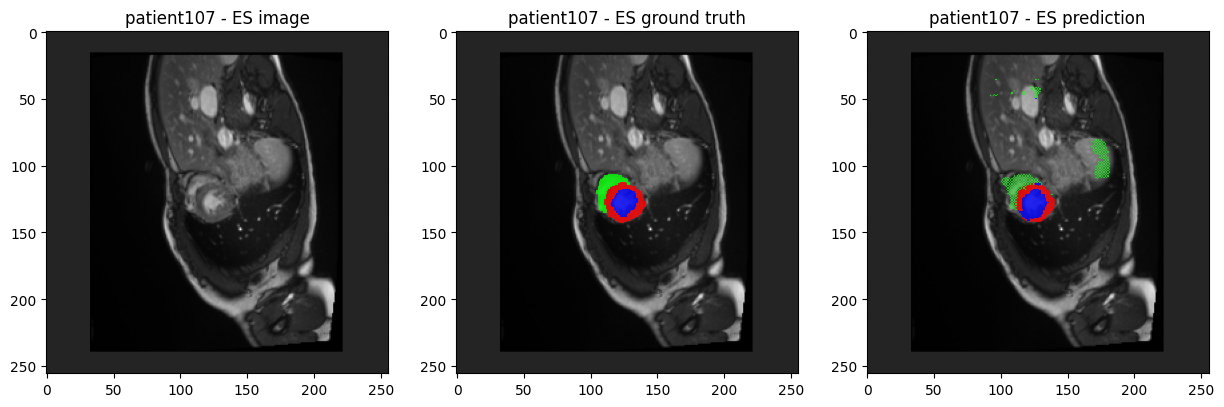

[0. 1. 2. 3.]
[0 1 2 3]


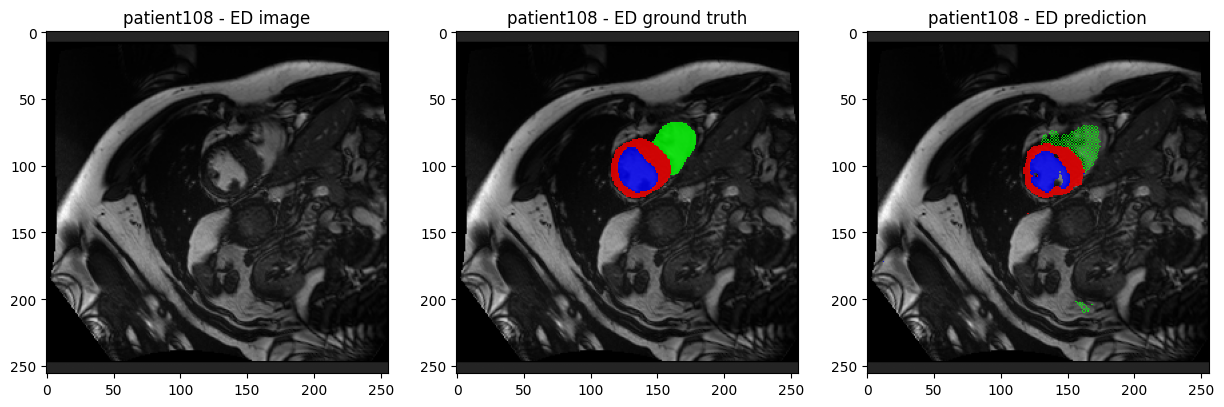

[0. 1. 2. 3.]
[0 1 2 3]


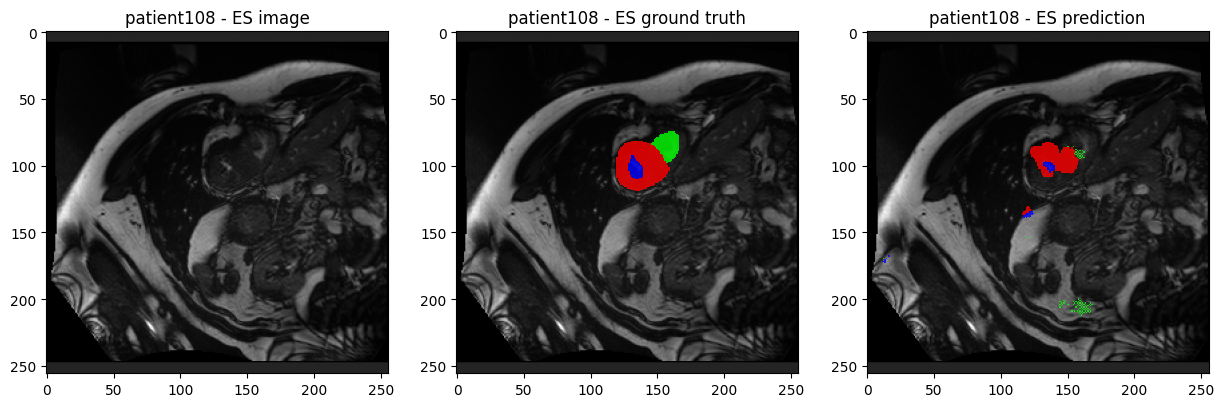

[0. 1. 2. 3.]
[0 1 2 3]


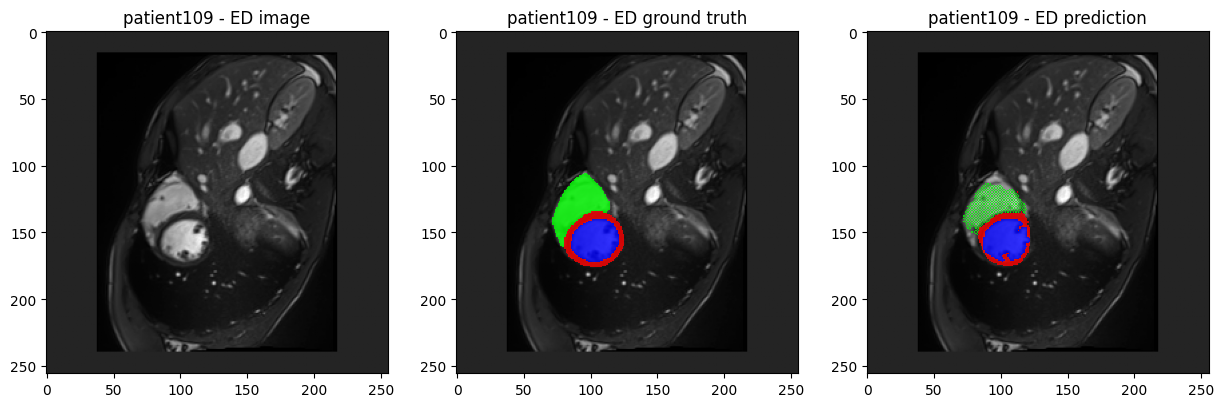

[0. 1. 2. 3.]
[0 1 2 3]


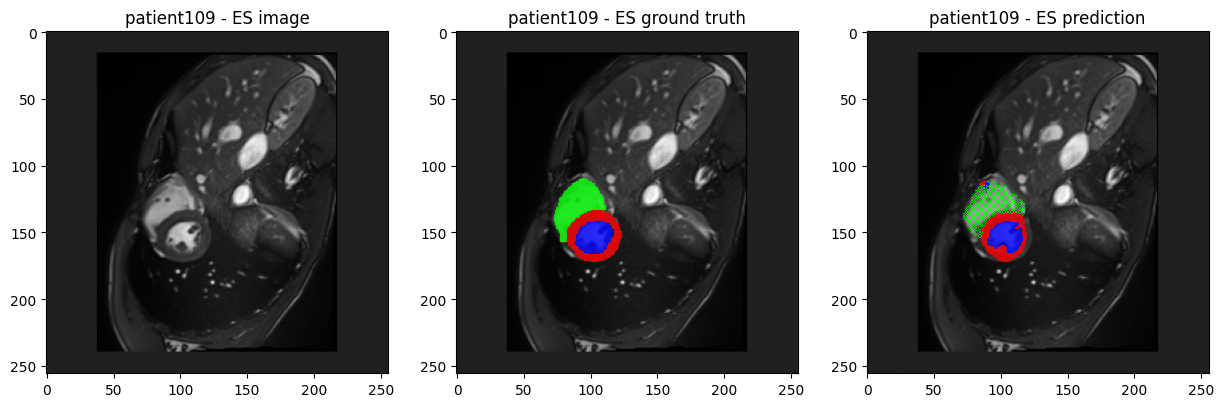

[0. 1. 2. 3.]
[0 1 2 3]


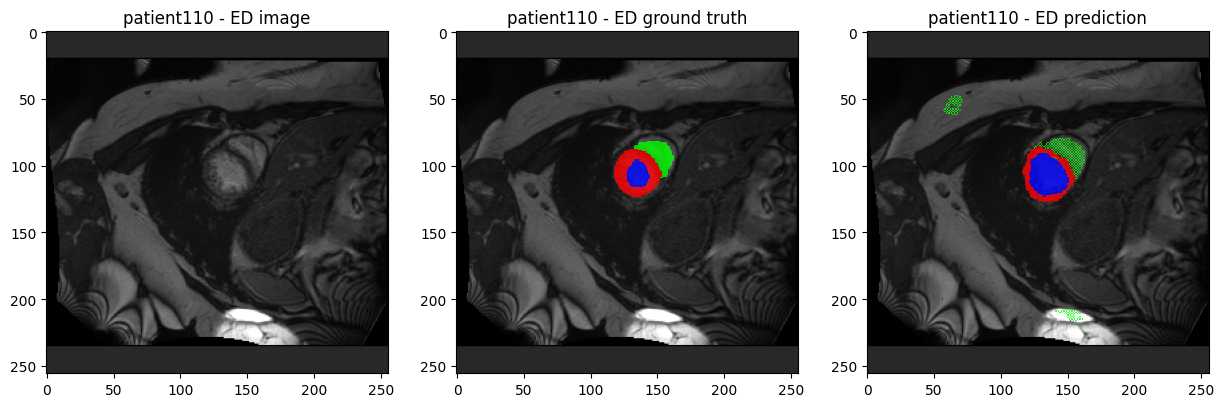

[0. 1. 2. 3.]
[0 1 2 3]


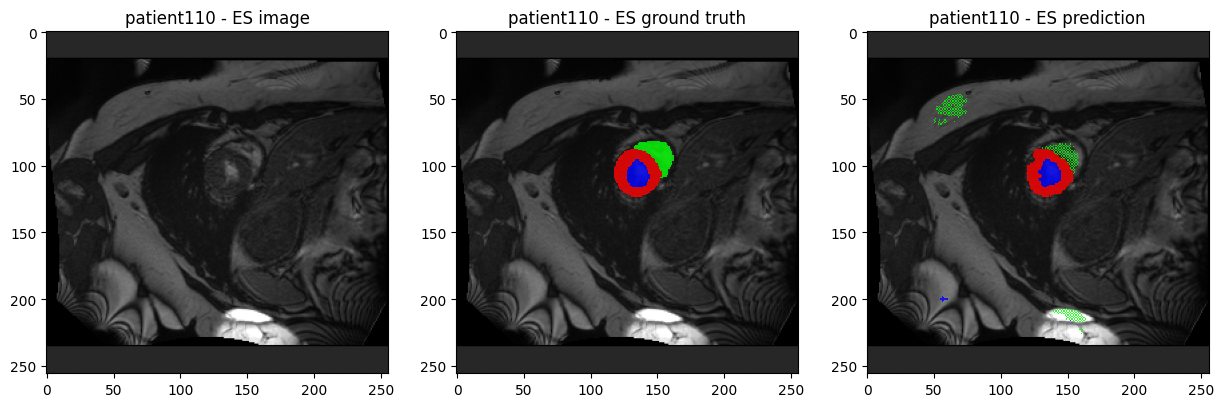

[0. 1. 2. 3.]
[0 1 2 3]


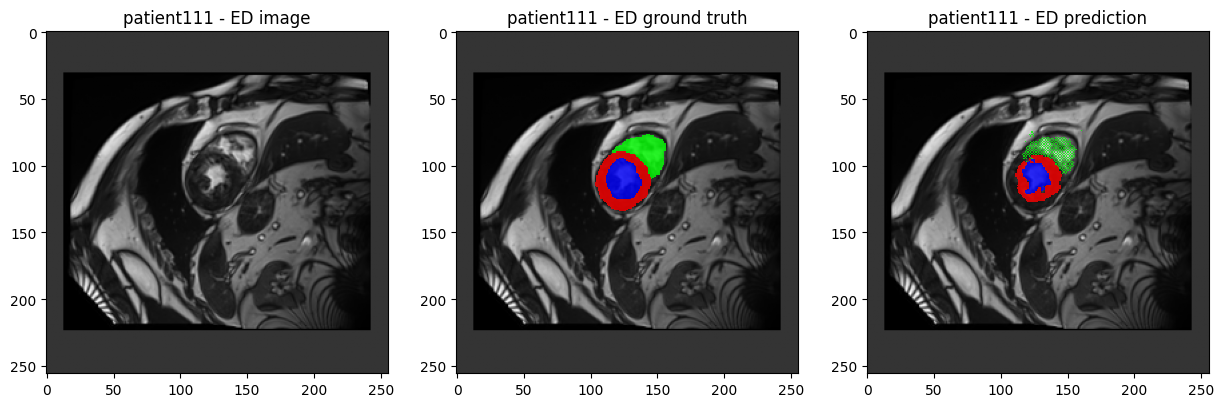

[0. 1. 2. 3.]
[0 1 2 3]


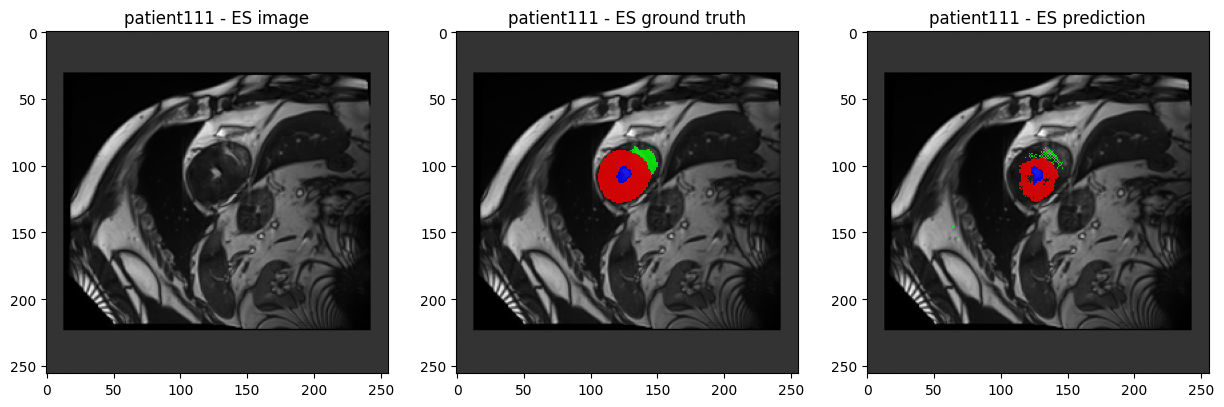

[0. 1. 2. 3.]
[0 1 2 3]


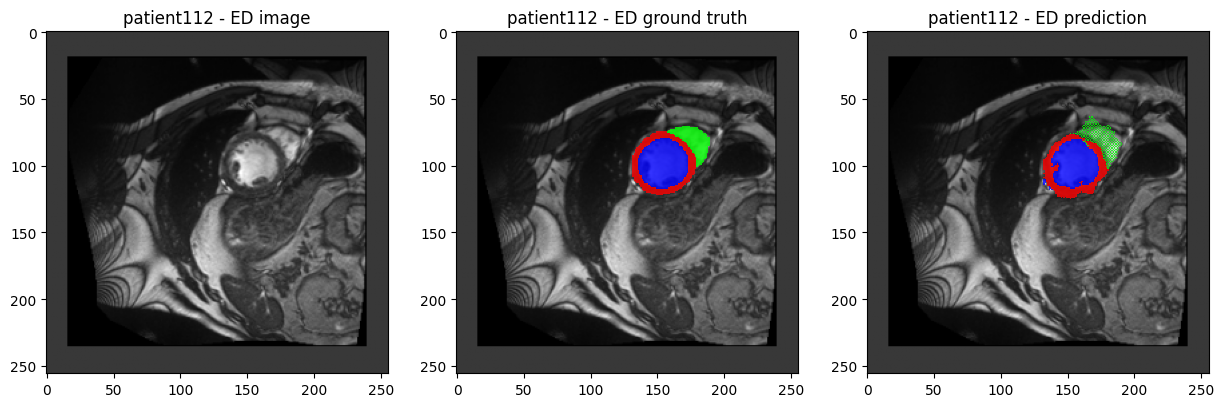

[0. 1. 2. 3.]
[0 1 2 3]


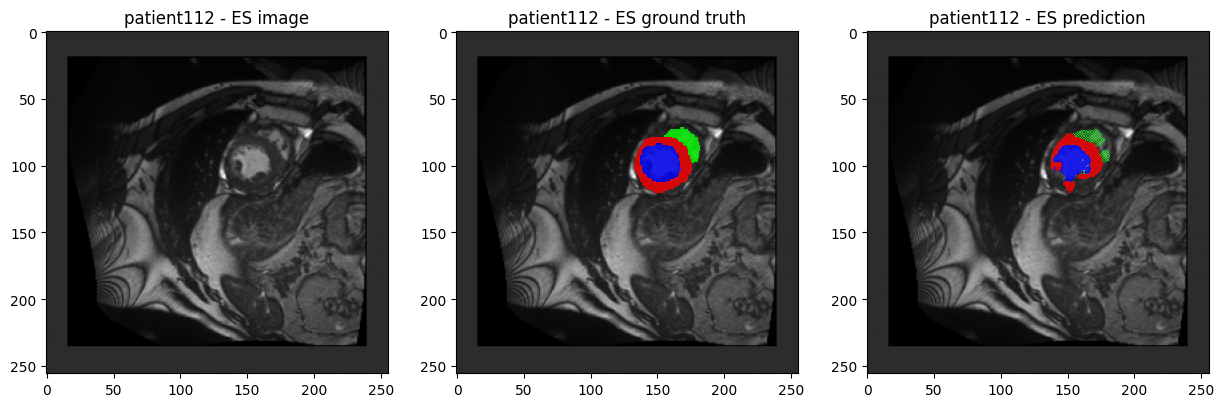

[0. 1. 2. 3.]
[0 1 2 3]


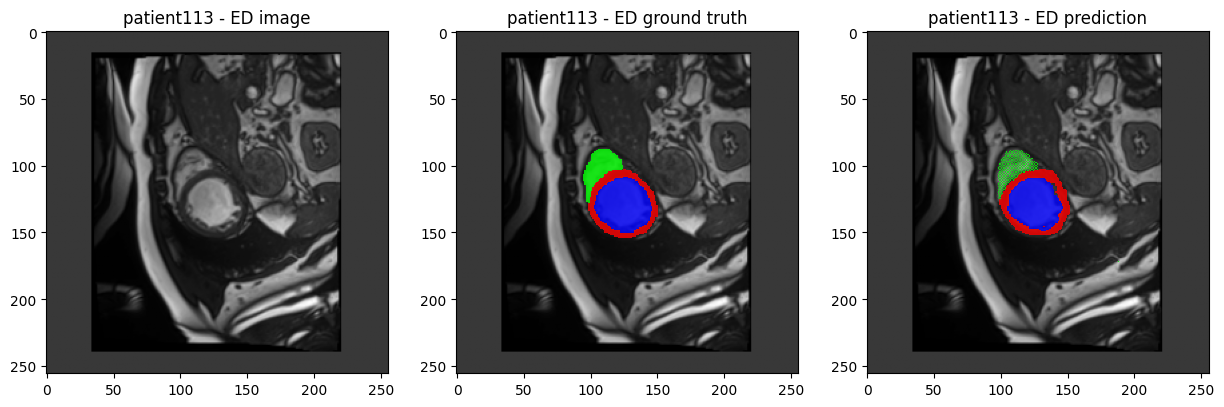

[0. 1. 2. 3.]
[0 1 2 3]


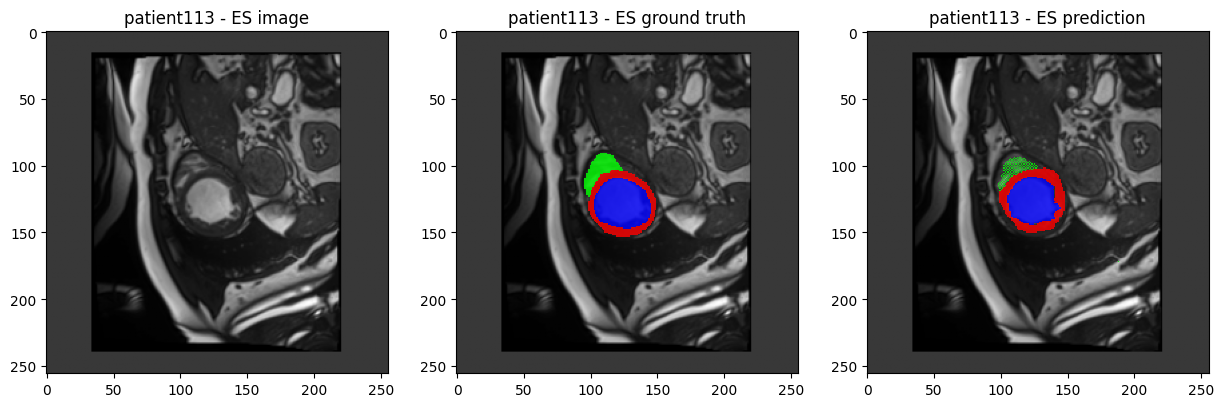

[0. 1. 2. 3.]
[0 1 2 3]


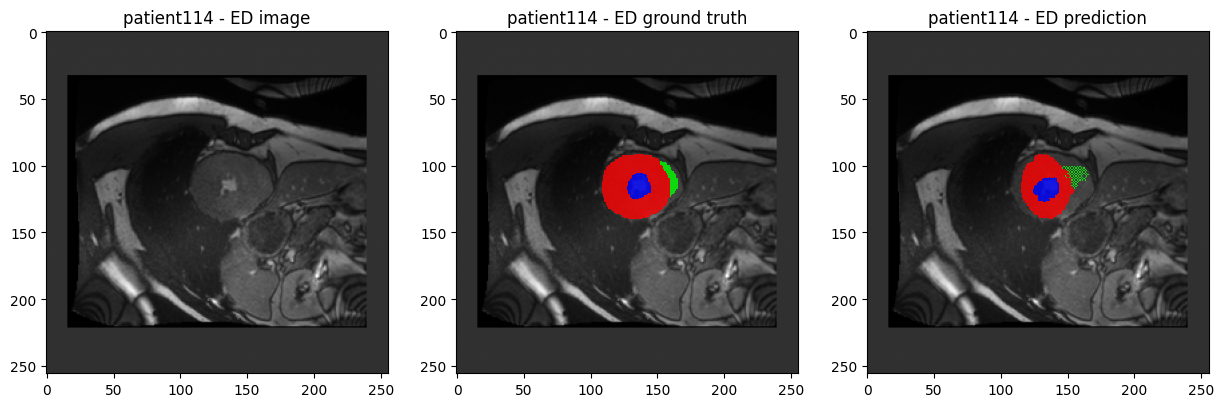

[0. 1. 2. 3.]
[0 1 2 3]


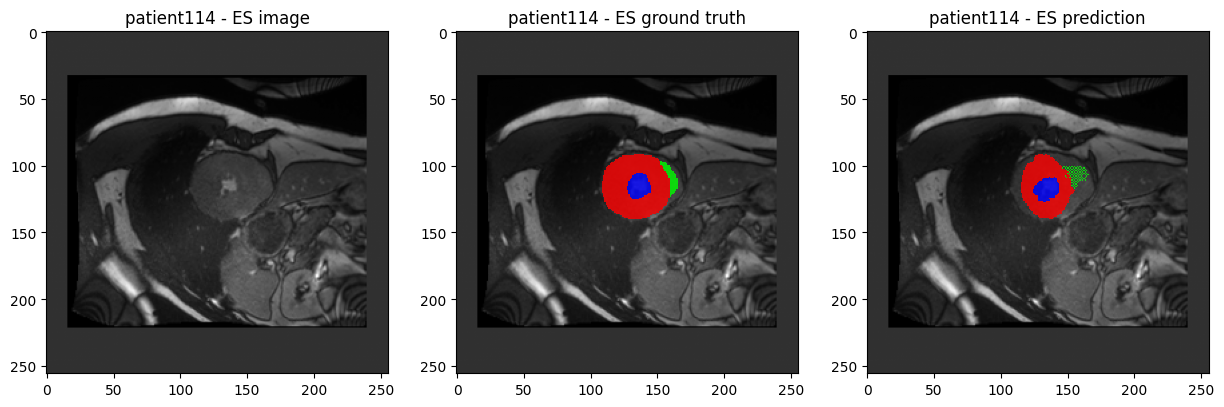

[0. 1. 2. 3.]
[0 1 2 3]


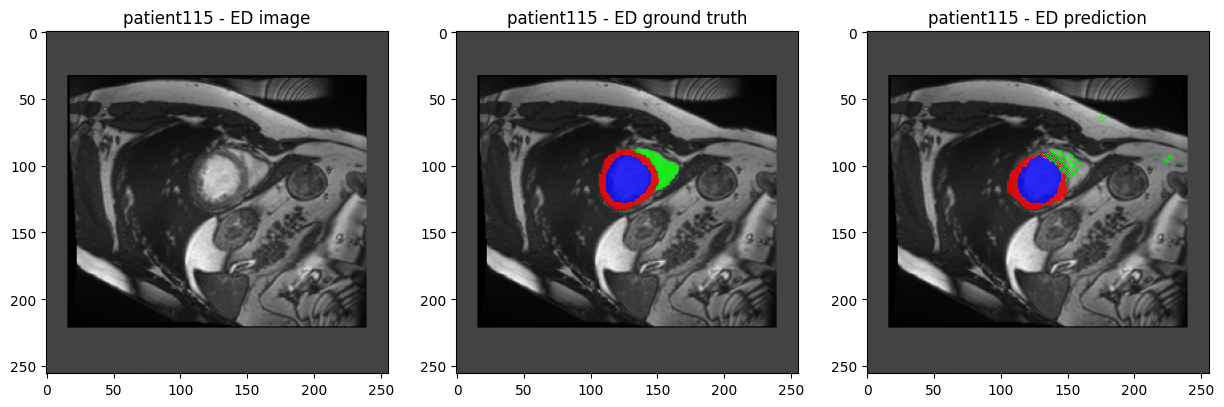

[0. 1. 2. 3.]
[0 1 2 3]


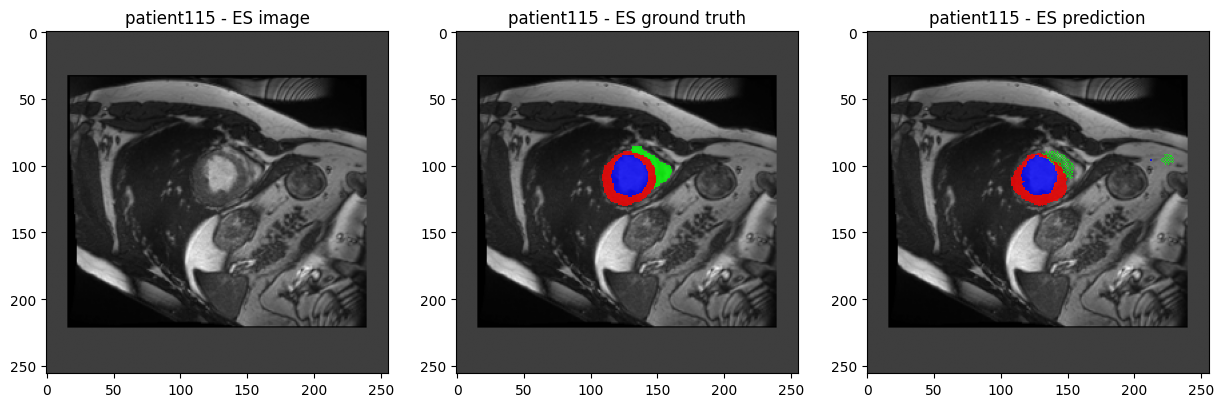

[0. 1. 2. 3.]
[0 1 2 3]


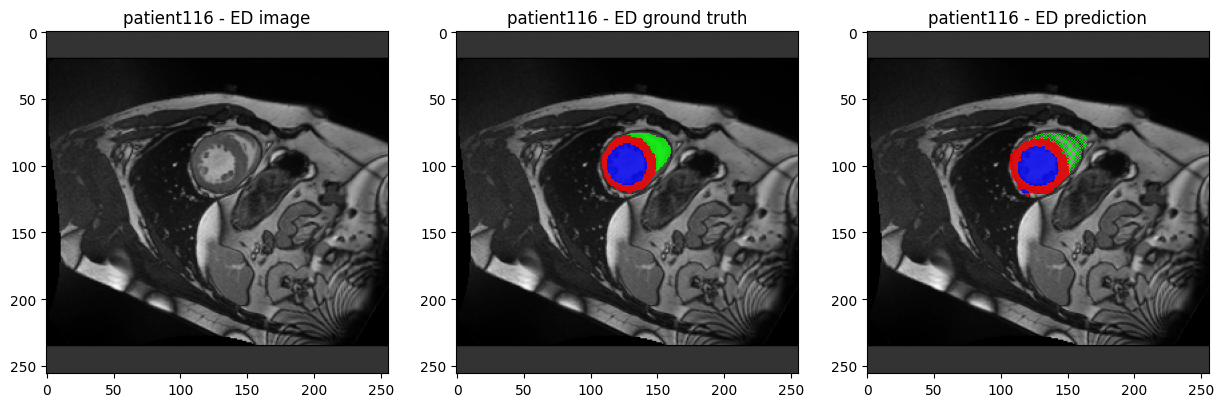

[0. 1. 2. 3.]
[0 1 2 3]


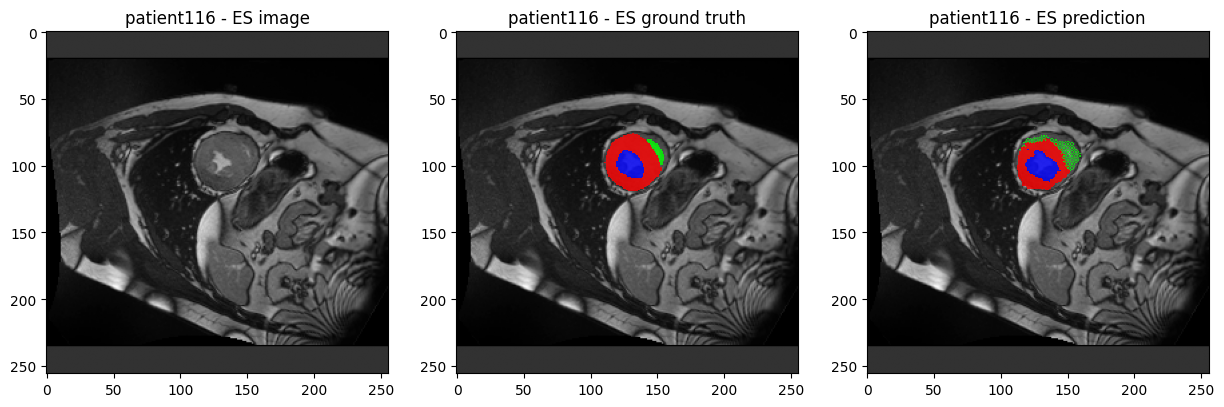

[0. 1. 2. 3.]
[0 1 2 3]


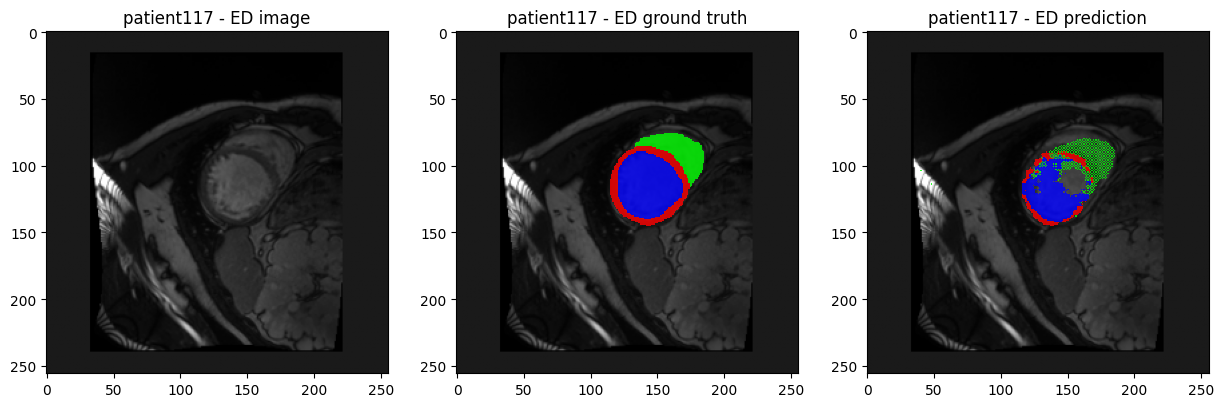

[0. 1. 2. 3.]
[0 1 2 3]


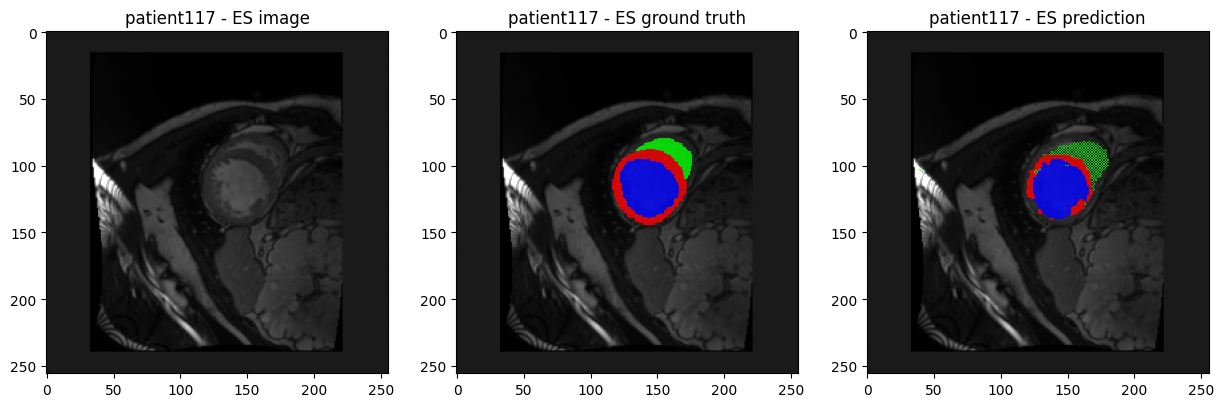

[0. 1. 2. 3.]
[0 1 2 3]


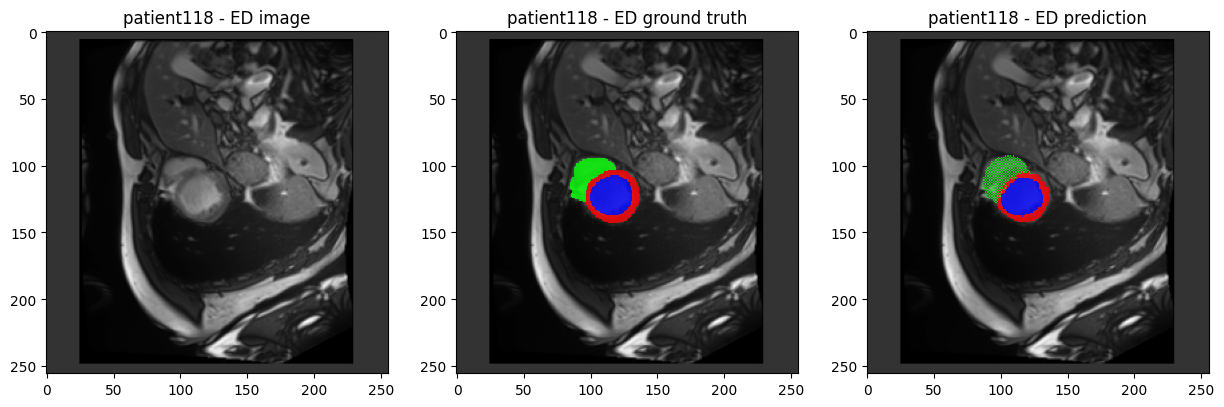

[0. 1. 2. 3.]
[0 1 2 3]


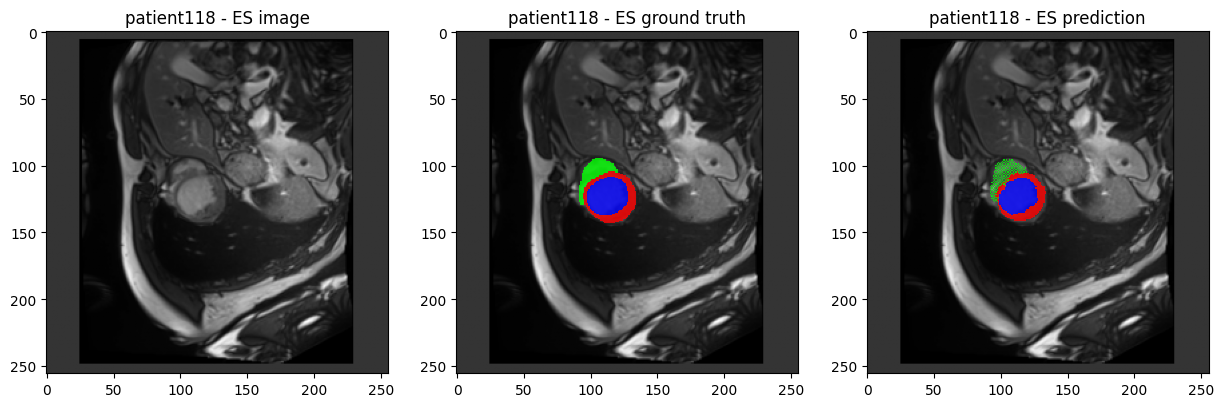

[0. 1. 2. 3.]
[0 1 2 3]


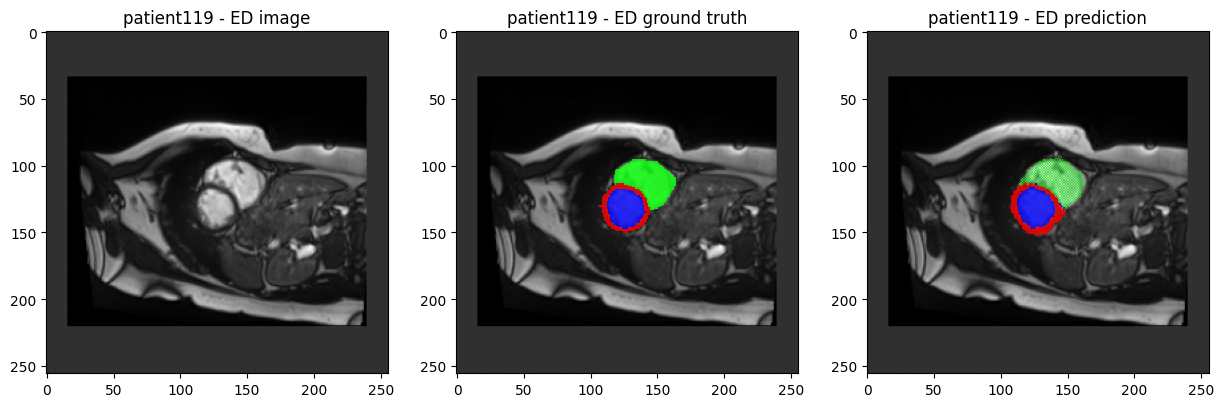

[0. 1. 2. 3.]
[0 1 2 3]


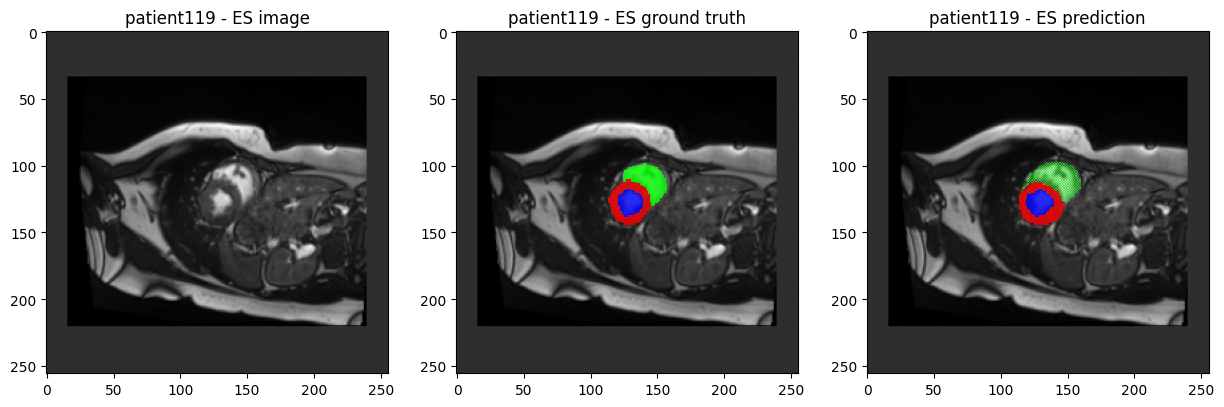

[0. 1. 2. 3.]
[0 1 2 3]


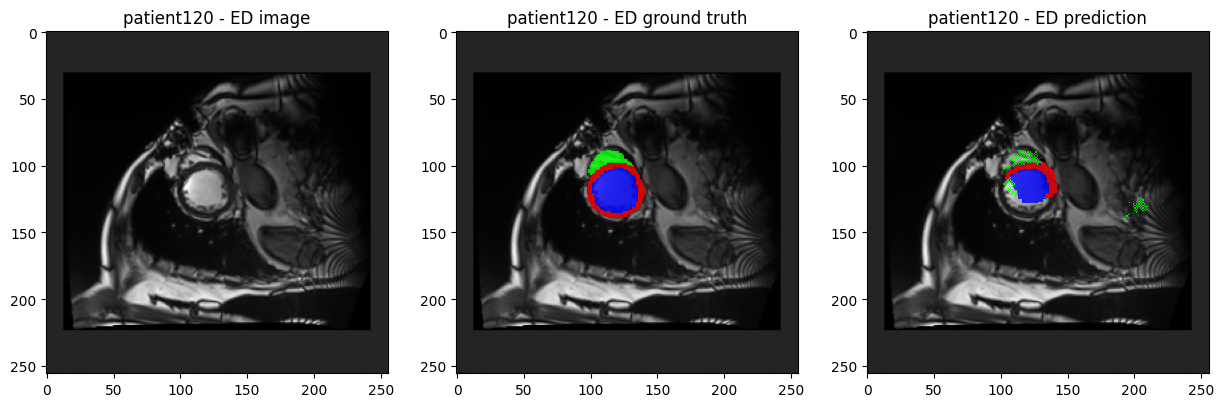

[0. 1. 2. 3.]
[0 1 2 3]


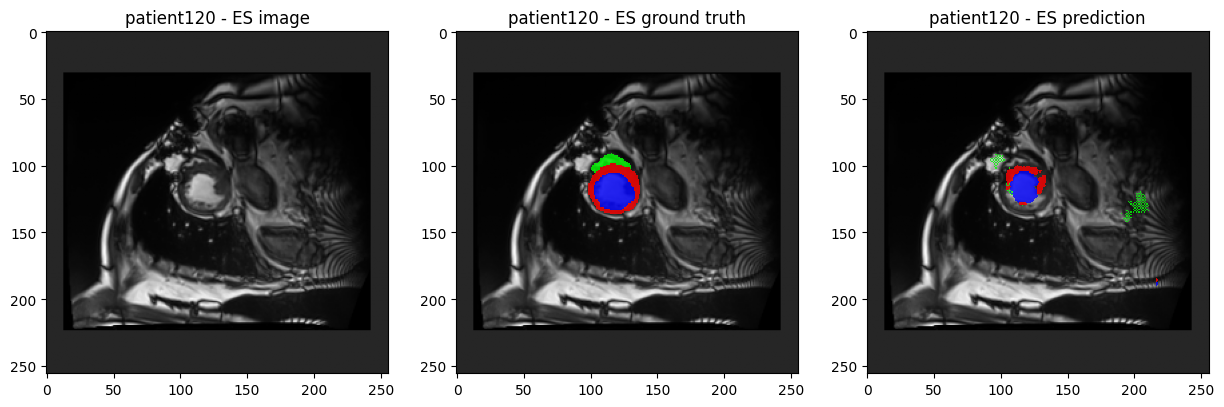

[0. 1. 2. 3.]
[0 1 2 3]


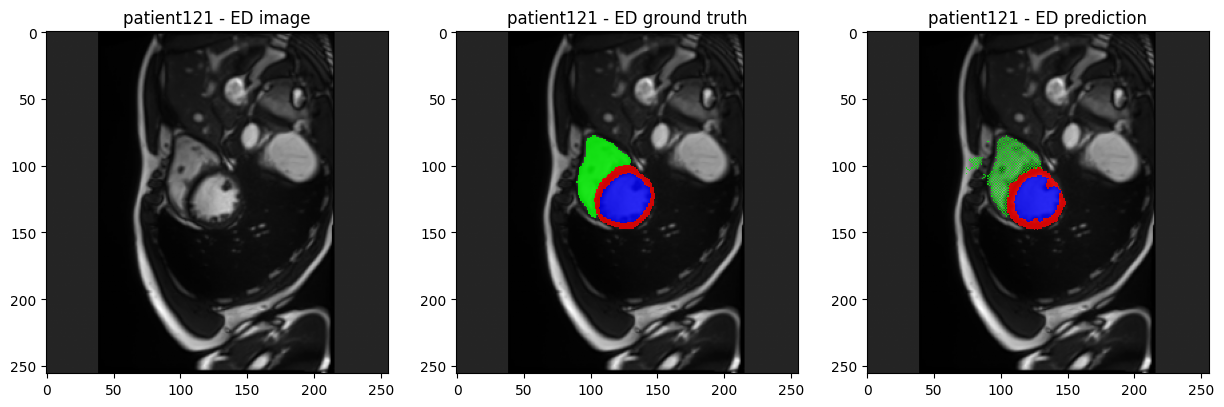

[0. 1. 2. 3.]
[0 1 2 3]


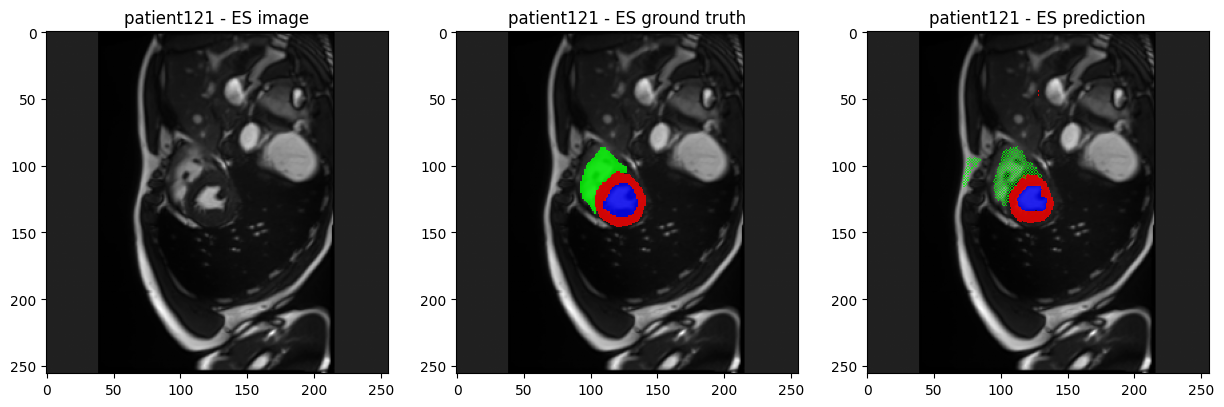

[0. 1. 2. 3.]
[0 1 2 3]


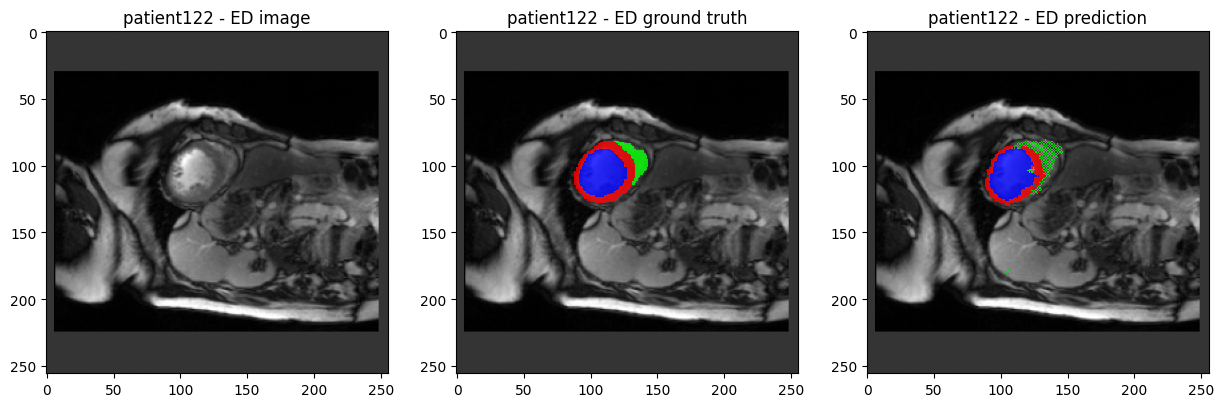

[0. 1. 2. 3.]
[0 1 2 3]


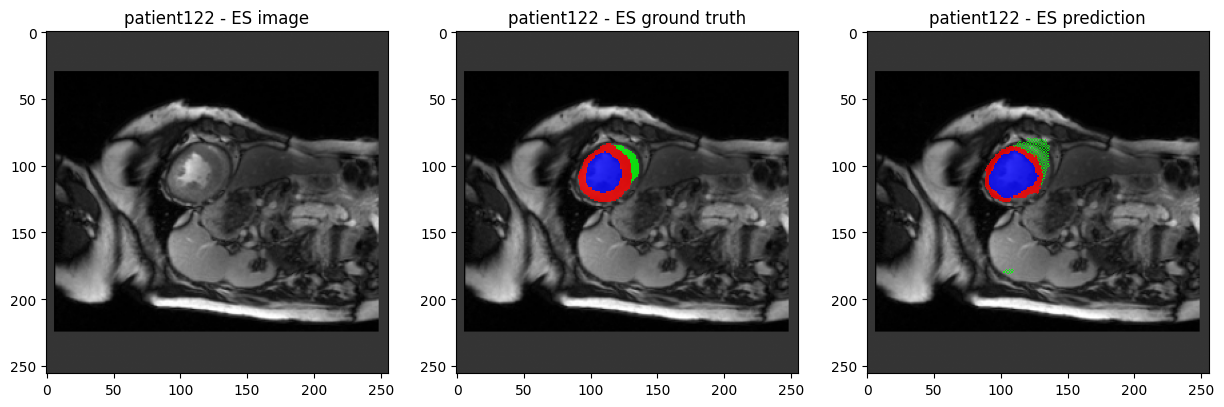

[0. 1. 2. 3.]
[0 1 2 3]


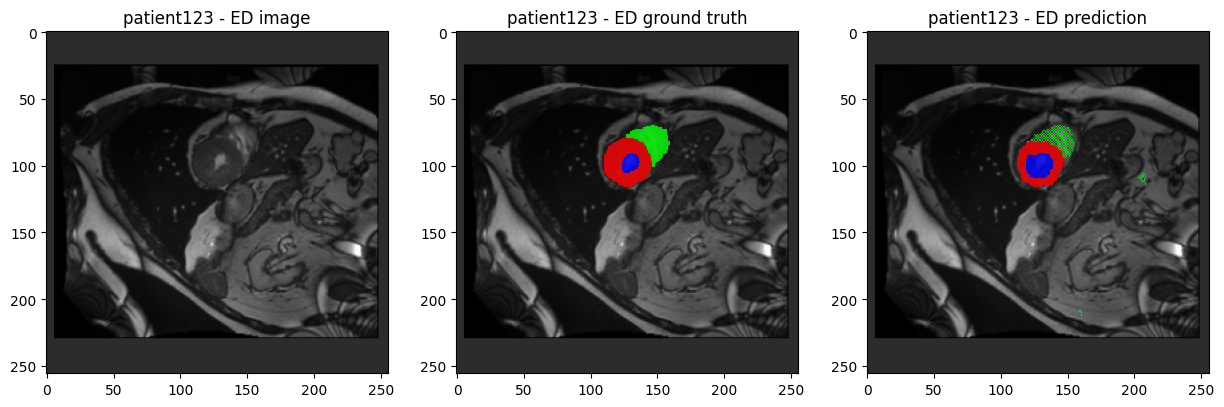

[0. 1. 2. 3.]
[0 1 2 3]


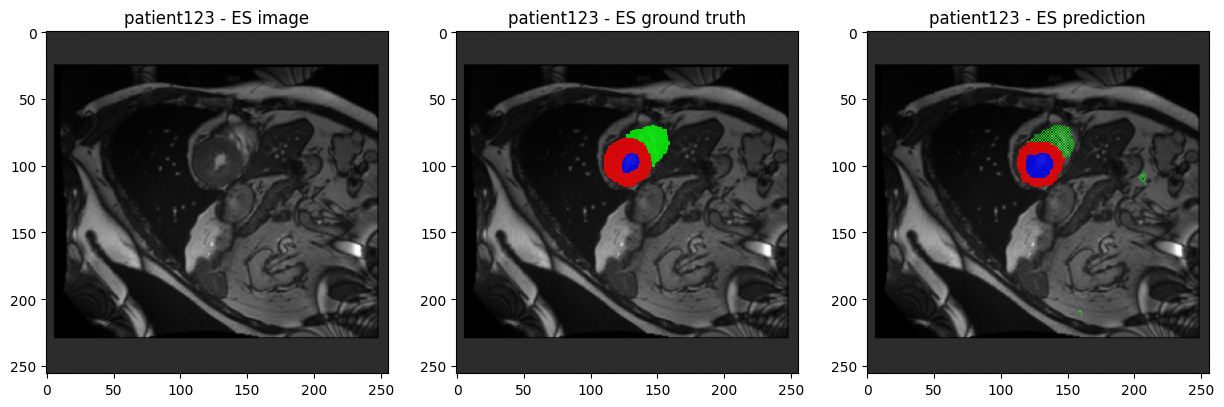

[0. 1. 2. 3.]
[0 1 2 3]


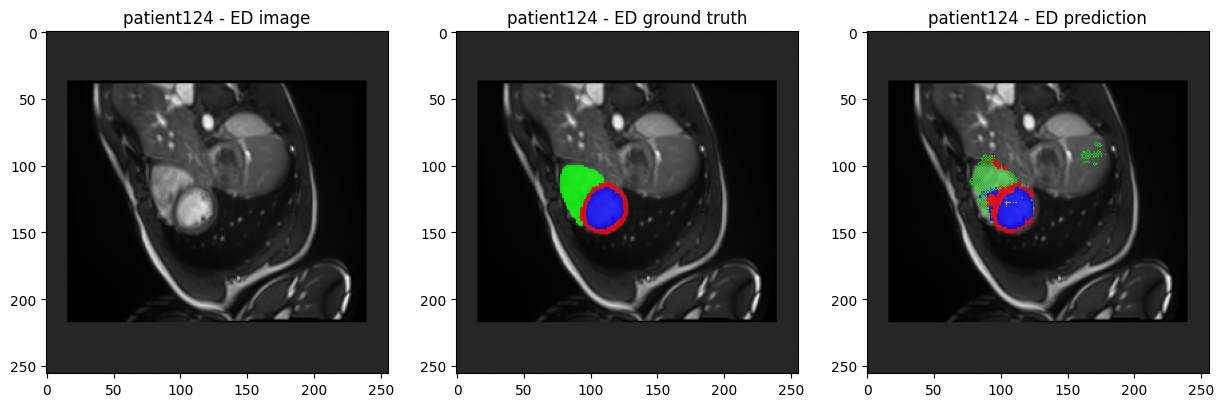

[0. 1. 2. 3.]
[0 1 2 3]


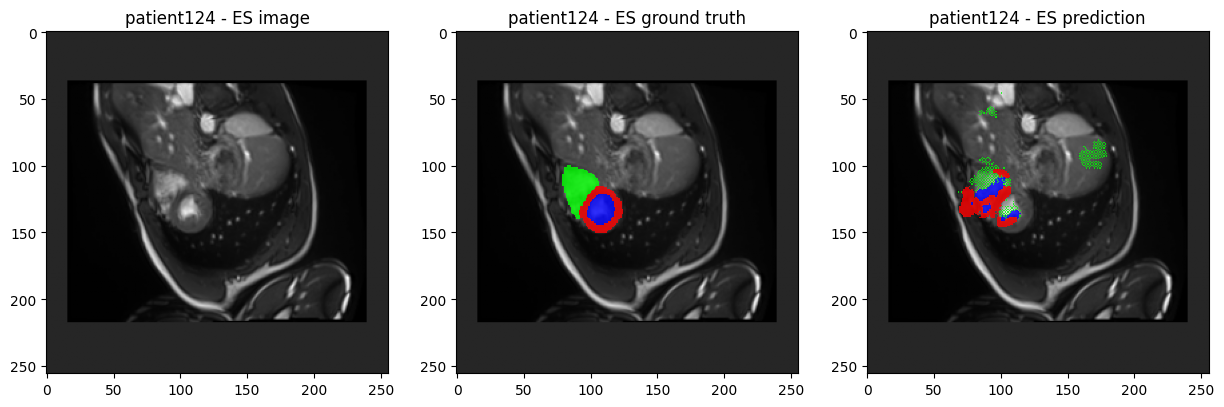

[0. 1. 2. 3.]
[0 1 2 3]


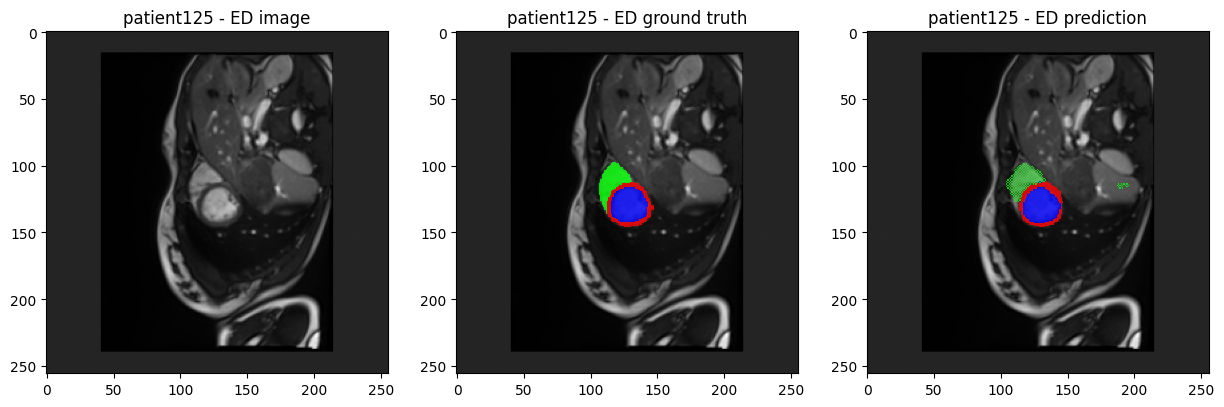

[0. 1. 2. 3.]
[0 1 2 3]


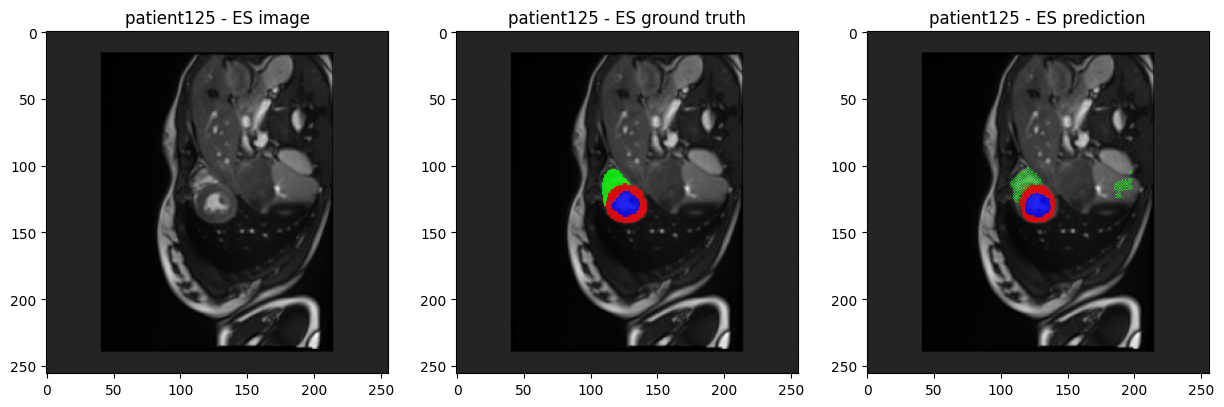

In [103]:
"""
# to test all slices for one patient
for i in range(16):
    sample = test_dataset[1]
    visual_evaluation(sample, model, indxslice=i)
"""

# to one slice for multiple patients
for i in range(25):
    sample = test_dataset[i]
    visual_evaluation(sample, model)